In [8]:
!pip -q install kagglehub pyarrow

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJ = '/content/drive/MyDrive/airline-cx-copilot'
DATA = f'{PROJ}/data'
os.makedirs(DATA, exist_ok=True)
print('Saving outputs to:', DATA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving outputs to: /content/drive/MyDrive/airline-cx-copilot/data


In [10]:
import glob
import kagglehub

try:
    path = kagglehub.dataset_download('juhibhojani/airline-reviews')
    csvs = glob.glob(f'{path}/**/*.csv', recursive=True)
except Exception as e:
    print('kagglehub download failed:', e)
    csvs = []

if not csvs:
    # Fallback: download the CSV manually from the Kaggle page, then upload it here
    from google.colab import files
    up = files.upload()
    csvs = [f'/content/{name}' for name in up.keys()]

print(csvs)

Using Colab cache for faster access to the 'airline-reviews' dataset.
['/kaggle/input/airline-reviews/Airline_review.csv']


In [11]:
import re
import numpy as np
import pandas as pd

raw = pd.read_csv(csvs[0])
print('Raw shape:', raw.shape)

def snake(c):
    return re.sub(r'[^0-9a-zA-Z]+', '_', c.strip()).strip('_').lower()

df = raw.copy()
df.columns = [snake(c) for c in df.columns]
df = df.drop(columns=[c for c in df.columns if c.startswith('unnamed')])
print(df.columns.tolist())
df.head(3)

Raw shape: (23171, 20)
['airline_name', 'overall_rating', 'review_title', 'review_date', 'verified', 'review', 'aircraft', 'type_of_traveller', 'seat_type', 'route', 'date_flown', 'seat_comfort', 'cabin_staff_service', 'food_beverages', 'ground_service', 'inflight_entertainment', 'wifi_connectivity', 'value_for_money', 'recommended']


,airline_name,overall_rating,review_title,review_date,verified,review,aircraft,type_of_traveller,seat_type,route,date_flown,seat_comfort,cabin_staff_service,food_beverages,ground_service,inflight_entertainment,wifi_connectivity,value_for_money,recommended
0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no


In [12]:
required = {'airline_name', 'overall_rating', 'review', 'recommended'}
missing = required - set(df.columns)
assert not missing, f'Columns not found: {missing}. Check the printed column list above and adjust the names.'

rating_cols = [c for c in ['seat_comfort', 'cabin_staff_service', 'food_beverages', 'ground_service',
                           'inflight_entertainment', 'wifi_connectivity', 'value_for_money'] if c in df.columns]

df['overall_rating'] = pd.to_numeric(df['overall_rating'], errors='coerce')
for c in rating_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['recommended_bin'] = df['recommended'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

for c in ['review_date', 'date_flown']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

# Strip the "Trip Verified |" style prefix
prefix = r'^\s*(?:✅\s*)?(?:Trip Verified|Not Verified|Verified Review)\s*\|\s*'
df['review_text'] = df['review'].astype(str).str.replace(prefix, '', regex=True).str.strip()
df['review_len'] = df['review_text'].str.len()

before = len(df)
df = df.dropna(subset=['overall_rating', 'recommended_bin'])
df = df[df['review_len'] >= 50]
df = df.drop_duplicates(subset=['review_text']).reset_index(drop=True)
df['review_id'] = df.index
print(f'Rows: {before} -> {len(df)} after cleaning')

/tmp/ipykernel_4226/1357192403.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors='coerce')


Rows: 23171 -> 22297 after cleaning


In [13]:
r1 = df[df['overall_rating'] == 1]
print('rating==1 rows:', len(r1), '| of which recommended=yes:', int(r1['recommended_bin'].sum()))
print(r1.groupby('recommended_bin')[rating_cols].mean().round(2))

rating==1 rows: 11583 | of which recommended=yes: 2264
                 seat_comfort  cabin_staff_service  food_beverages  \
recommended_bin                                                      
0                        1.56                 1.68            1.42   
1                        4.56                 4.86            4.52   

                 ground_service  inflight_entertainment  wifi_connectivity  \
recommended_bin                                                              
0                          1.19                    1.39               1.17   
1                          4.74                    3.96               4.19   

                 value_for_money  
recommended_bin                   
0                           1.18  
1                           4.68  


In [14]:
mask = (df['overall_rating'] == 1) & (df['recommended_bin'] == 1)
print('Reassigning', int(mask.sum()), 'rows 1 -> 10')
df.loc[mask, 'overall_rating'] = 10
print(df['overall_rating'].value_counts().sort_index())

Reassigning 2264 rows 1 -> 10
overall_rating
1.0     9319
2.0     2294
3.0     1353
4.0      853
5.0      826
6.0      672
7.0     1193
8.0     1756
9.0     1767
10.0    2264
Name: count, dtype: int64


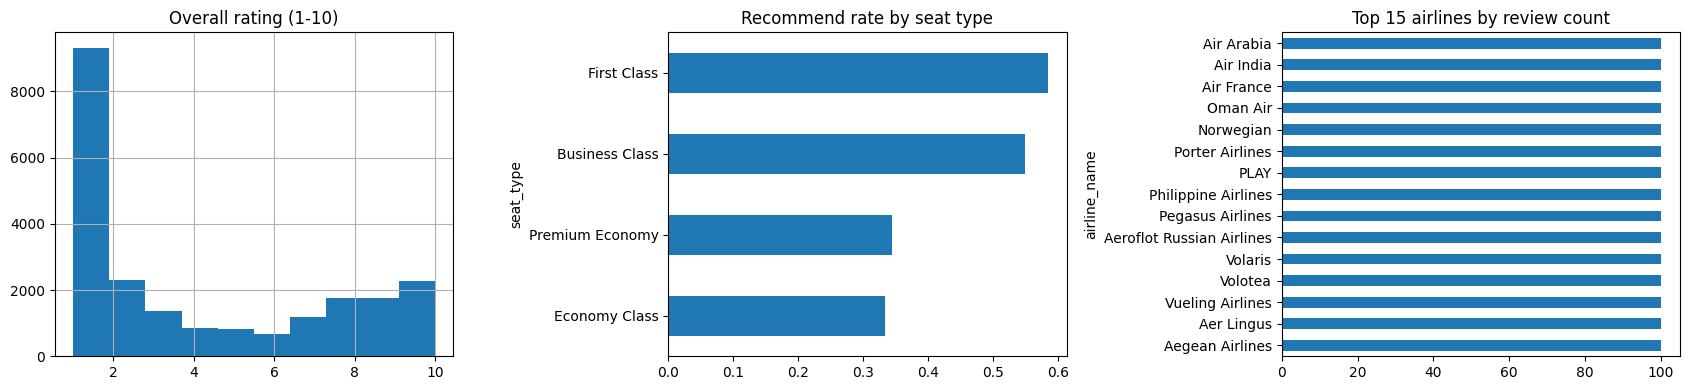

Recommend rate:
 recommended_bin
0    0.65
1    0.35
Name: proportion, dtype: float64

Missing share of sub-ratings:
 seat_comfort              0.16
cabin_staff_service       0.16
food_beverages            0.36
ground_service            0.18
inflight_entertainment    0.52
wifi_connectivity         0.73
value_for_money           0.02
dtype: float64

Median review length (chars): 559


In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
df['overall_rating'].hist(bins=10, ax=ax[0])
ax[0].set_title('Overall rating (1-10)')
if 'seat_type' in df.columns:
    df.groupby('seat_type')['recommended_bin'].mean().sort_values().plot.barh(ax=ax[1])
ax[1].set_title('Recommend rate by seat type')
df['airline_name'].value_counts().head(15).sort_values().plot.barh(ax=ax[2])
ax[2].set_title('Top 15 airlines by review count')
plt.tight_layout()
plt.show()

print('Recommend rate:\n', df['recommended_bin'].value_counts(normalize=True).round(3))
print('\nMissing share of sub-ratings:\n', df[rating_cols].isna().mean().round(2))
print('\nMedian review length (chars):', int(df['review_len'].median()))

In [16]:
SAMPLE_N = 8000

keep = ['review_id', 'airline_name', 'overall_rating', 'recommended_bin', 'review_text', 'review_len',
        'seat_type', 'type_of_traveller', 'route', 'review_date', 'date_flown', 'verified'] + rating_cols
keep = [c for c in keep if c in df.columns]

sample = df.sample(n=min(SAMPLE_N, len(df)), random_state=42).reset_index(drop=True)

df[keep].to_parquet(f'{DATA}/reviews_clean.parquet', index=False)
sample[keep].to_parquet(f'{DATA}/reviews_sample.parquet', index=False)

for f in ['reviews_clean.parquet', 'reviews_sample.parquet']:
    print(f, round(os.path.getsize(f'{DATA}/{f}') / 1e6, 1), 'MB')

reviews_clean.parquet 9.8 MB
reviews_sample.parquet 3.7 MB
